In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Telco_customer_churn.csv")



**Basic Data Understanding**

In [5]:
df.shape

(7043, 33)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [8]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [13]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [10]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [14]:
df['Count'].value_counts()

,count
Count,
1,7043


In [17]:
df['CustomerID'].nunique()


7043

In [18]:
df['Country'].value_counts()

,count
Country,
United States,7043


In [19]:
df['State'].nunique()
df['City'].nunique()

1129

In [20]:
df.groupby('State')['Churn Value'].mean().sort_values(ascending=False)

,Churn Value
State,
California,0.26537


In [21]:
df.groupby('City')['Churn Value'].mean().sort_values(ascending=False)

,Churn Value
City,
Wrightwood,1.0
Tipton,1.0
Truckee,1.0
Twain,1.0
Johannesburg,1.0
...,...
La Crescenta,0.0
San Miguel,0.0
Montara,0.0


In [22]:
df['Churn Score'].describe()
df.groupby('Churn Value')['Churn Score'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,50.098183,17.702277,5.0,35.0,50.0,66.0,80.0
1,1869.0,82.510433,10.328570,65.0,74.0,82.0,91.0,100.0


In [23]:
df[['Churn Score','Churn Value']].corr()

,Churn Score,Churn Value
Churn Score,1.000000,0.664897
Churn Value,0.664897,1.000000


In [24]:
drop_cols = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'City'
]

df = df.drop(columns=drop_cols)

In [25]:
df.shape

(7043, 28)

In [26]:
df.columns

Index(['Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [28]:
df['Zip Code']

,Zip Code
0,90003
1,90005
2,90006
3,90010
4,90015
...,...
7038,92285
7039,92301
7040,92304
7041,92305


In [29]:
drop_cols = [
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude'
]

df = df.drop(columns=drop_cols)

In [30]:
df.shape

(7043, 24)

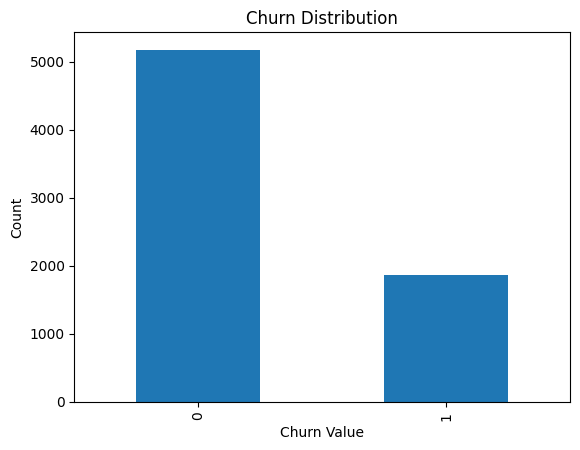

In [34]:
df['Churn Value'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.xlabel('Churn Value')
plt.ylabel('Count')
plt.show()

In [36]:
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


In [37]:
df.groupby('Churn Value')['Tenure Months'].mean()

,Tenure Months
Churn Value,
0,37.569965
1,17.979133


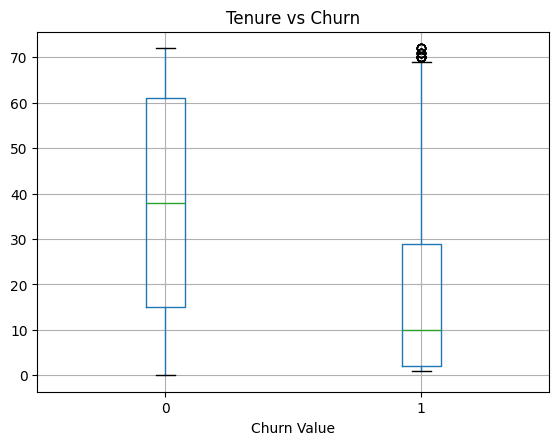

In [39]:

df.boxplot(column='Tenure Months', by='Churn Value')
plt.title("Tenure vs Churn")
plt.suptitle("")
plt.show()

In [41]:
df.groupby('Churn Value')['Monthly Charges'].mean()

,Monthly Charges
Churn Value,
0,61.265124
1,74.441332


In [44]:
pd.crosstab(df['Contract'], df['Churn Value'], normalize='index') * 100

Churn Value,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [45]:
pd.crosstab(df['Internet Service'], df['Churn Value'], normalize='index') * 100

Churn Value,0,1
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [46]:
pd.crosstab(df['Tech Support'], df['Churn Value'], normalize='index') * 100

Churn Value,0,1
Tech Support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [49]:
leakage_cols = ['Churn Label', 'Churn Score', 'Churn Reason', 'CLTV']

df = df.drop(columns=leakage_cols)

In [50]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='object')

In [51]:
# =========================
# IMPORTS
# =========================
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# =========================
# SPLIT FEATURES / TARGET
# =========================
X = df.drop('Churn Value', axis=1)
y = df['Churn Value']

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# COLUMN TYPES
# =========================
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# =========================
# PREPROCESSOR
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# =========================
# MODEL
# =========================
model = LogisticRegression(max_iter=1000)

# =========================
# FULL PIPELINE
# =========================
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# =========================
# TRAIN MODEL
# =========================
clf.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================
y_pred = clf.predict(X_test)

# =========================
# EVALUATION
# =========================
print("CONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

CONFUSION MATRIX:
[[915 120]
 [160 214]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [52]:
X_train.shape

(5634, 19)

In [53]:
X_test.shape

(1409, 19)

In [54]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# =========================
# 1. SPLIT FEATURES / TARGET
# =========================
X = df.drop('Churn Value', axis=1)
y = df['Churn Value']

# =========================
# 2. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 3. COLUMN TYPES
# =========================
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# =========================
# 4. PREPROCESSOR
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# =========================
# 5. MODEL (IMPROVED)
# =========================
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

# =========================
# 6. FULL PIPELINE
# =========================
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# =========================
# 7. TRAIN MODEL
# =========================
clf.fit(X_train, y_train)

# =========================
# 8. PREDICTIONS
# =========================
y_pred = clf.predict(X_test)

# =========================
# 9. EVALUATION
# =========================
print("CONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

CONFUSION MATRIX:
[[723 312]
 [ 77 297]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1035
           1       0.49      0.79      0.60       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.72      0.74      1409

